In [13]:
import random
from pathlib import Path
import numpy as np

def generate_random_qasm_circuit(
    num_qubits: int,
    depth: int,
    single_qubit_gate_percentage: float,
    two_qubit_gate_percentage: float,
    output_path: Path | None = None,
    seed: int | None = None,
    worst_case: bool = False,
    num_clusters: int | None = None,
    layers_per_slice: int | None = None,
) -> str:
    """
    Generate a random QASM 2.0 circuit.

    Parameters:
    -----------
    num_qubits: Number of qubits in the circuit
    depth: Number of layers (even layers = single-qubit, odd layers = two-qubit)
    single_qubit_gate_percentage: Percentage of qubits to apply single-qubit gates to (0.0-1.0)
    two_qubit_gate_percentage: Percentage of qubit pairs to apply CNOT gates to (0.0-1.0)
    output_path: Optional path to save the QASM file
    seed: Random seed for reproducibility
    worst_case: If True, build two-qubit layers to maximize partition churn between layers
    num_clusters: Number of clusters to partition qubits into (required when worst_case is True)
    layers_per_slice: Number of slices per two-qubit layer (required when worst_case is True)

    Returns:
    --------
    qasm_string: The generated QASM circuit as a string
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    if worst_case:
        if num_clusters is None or layers_per_slice is None:
            raise ValueError("num_clusters and layers_per_slice must be provided when worst_case is True.")
        if num_clusters <= 0 or layers_per_slice <= 0:
            raise ValueError("num_clusters and layers_per_slice must be positive when worst_case is True.")

    def build_partition(previous_partition: list[list[int]] | None) -> list[list[int]]:
        base_size = num_qubits // num_clusters
        remainder = num_qubits % num_clusters
        cluster_sizes = [base_size + 1 if i < remainder else base_size for i in range(num_clusters)]

        attempts = max(25, num_clusters * 5)
        best_partition: list[list[int]] | None = None
        best_overlap = None

        for _ in range(attempts):
            qubits = list(range(num_qubits))
            random.shuffle(qubits)

            partition = []
            idx = 0
            for size in cluster_sizes:
                partition.append(qubits[idx:idx + size])
                idx += size

            overlap = 0
            if previous_partition:
                for i, cluster in enumerate(partition):
                    if i < len(previous_partition):
                        overlap += len(set(cluster) & set(previous_partition[i]))

            if best_overlap is None or overlap < best_overlap:
                best_partition = [c[:] for c in partition]
                best_overlap = overlap
                if best_overlap == 0:
                    break

        return best_partition or partition


    # Start building QASM content
    qasm_lines = [
        "//",
        "//",
        "//",
        "//",
        "",
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        "",
        f"qreg q[{num_qubits}];",
        ""
    ]

    previous_partition: list[list[int]] | None = None
    partition: list[list[int]] | None = None

    gate_counter = 0

    # Generate circuit layers
    for layer in range(depth):
        if worst_case:
            if layer == 0 or layer % layers_per_slice == 0:
                print(f"Number of gates: {gate_counter}")
                print("NEW PARTITION")
                partition = build_partition(previous_partition)
                previous_partition = partition
                if layer > 0:
                    qasm_lines.append('barrier q;')
                    qasm_lines.append('')
            
        if layer % 2 == 0:
            # Even layers: single-qubit gates
            num_gates = int(num_qubits * single_qubit_gate_percentage)
            if num_gates > 0:
                selected_qubits = random.sample(range(num_qubits), num_gates)

                for qubit in sorted(selected_qubits):
                    # Randomly choose between u1, u2, u3 gates with random parameters
                    gate_type = random.choice(['u1', 'u2', 'u3'])

                    if gate_type == 'u1':
                        theta = round(random.uniform(0, 2 * np.pi), 2)
                        qasm_lines.append(f"u1({theta}) q[{qubit}];")
                    elif gate_type == 'u2':
                        phi = round(random.uniform(0, 2 * np.pi), 2)
                        lam = round(random.uniform(0, 2 * np.pi), 2)
                        qasm_lines.append(f"u2({phi},{lam}) q[{qubit}];")
                    else:  # u3
                        theta = round(random.uniform(0, np.pi), 2)
                        phi = round(random.uniform(0, 2 * np.pi), 2)
                        lam = round(random.uniform(0, 2 * np.pi), 2)
                        qasm_lines.append(f"u3({theta},{phi},{lam}) q[{qubit}];")
                    
                    gate_counter += 1

                qasm_lines.append("")  # Empty line after layer

        else:
            # Odd layers: two-qubit gates (CNOT)
            # Generate random pairs
            max_pairs = num_qubits // 2
            num_pairs = int(max_pairs * two_qubit_gate_percentage)

            if num_pairs > 0:
                if worst_case:

                    print("Partitition:", partition)
                    
                    pairs = []

                    # Randomly select pairs from within each partition slice
                    for slice_group in partition:
                        #print("Slice group:", slice_group)
                        available_qubits = slice_group[:]
                        random.shuffle(available_qubits)
                        num_pairs_local = round(num_pairs / len(partition))
                        current_pairs_local = 0

                        # Create pairs within this slice
                        while len(available_qubits) >= 2 and current_pairs_local < num_pairs_local:
                            control = available_qubits.pop()
                            target = available_qubits.pop()
                            current_pairs_local += 1
                            pairs.append((control, target))


                else:
                    available_qubits = list(range(num_qubits))
                    pairs = []

                    random.shuffle(available_qubits)

                    for i in range(num_pairs):
                        if len(available_qubits) >= 2:
                            control = available_qubits.pop()
                            target = available_qubits.pop()
                            pairs.append((control, target))

                # Sort pairs for consistent ordering
                for control, target in sorted(pairs):
                    qasm_lines.append(f"cx q[{control}],q[{target}];")
                    gate_counter += 1

                qasm_lines.append("")  # Empty line after layer

    # Join all lines
    qasm_content = "\n".join(qasm_lines)


    # Save to file if path provided
    if output_path:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        with open(output_path, 'w') as f:
            f.write(qasm_content)
        print(f"Circuit saved to: {output_path}")

    return qasm_content


In [17]:
# Example usage: Generate a random circuit

for num_c in [4]:

    num_qubits_list = range(4,61)

    single_qubit_gate_percentage = 1.0 # % of qubits get single-qubit gates
    two_qubit_gate_percentage = 1.0    # % of possible pairs get CNOT gates
    worst_case = True
    num_clusters = num_c
    layers_per_slice = 4
    depth_factor = 2


    worst_case_string = f"_worstcase_{num_clusters}part_{layers_per_slice}lps" if worst_case else ""

    output_title = f"generated_{single_qubit_gate_percentage}_{two_qubit_gate_percentage}{worst_case_string}"

    path = f"../inputs/qasm_files/{output_title}"

    # Create directory if it doesn't exist
    if not Path(path).exists():
        Path(path).mkdir(parents=True, exist_ok=True)

    output_dir = Path(path)

    for num_qubits in num_qubits_list:
        depth = depth_factor*num_qubits
        output_file = output_dir / f"{output_title}_{num_qubits}.qasm"

        # Generate the circuit
        circuit = generate_random_qasm_circuit(
            num_qubits=num_qubits,
            depth=depth,
            single_qubit_gate_percentage=single_qubit_gate_percentage,
            two_qubit_gate_percentage=two_qubit_gate_percentage,
            output_path=output_file,  
            worst_case=worst_case,
            num_clusters=num_clusters,
            layers_per_slice=layers_per_slice
        )

        print(f"\nGenerated circuit with {num_qubits} qubits and {depth} layers")
        print(f"\nFirst few lines:")
        print("\n".join(circuit.split("\n")[:20]))

Number of gates: 0
NEW PARTITION
Partitition: [[2], [1], [0], [3]]
Partitition: [[2], [1], [0], [3]]
Number of gates: 8
NEW PARTITION
Partitition: [[0], [3], [1], [2]]
Partitition: [[0], [3], [1], [2]]
Circuit saved to: ../inputs/qasm_files/generated_1.0_1.0_worstcase_4part_4lps/generated_1.0_1.0_worstcase_4part_4lps_4.qasm

Generated circuit with 4 qubits and 8 layers

First few lines:
//
//
//
//

OPENQASM 2.0;
include "qelib1.inc";

qreg q[4];

u2(1.69,0.34) q[0];
u2(3.7,2.49) q[1];
u2(0.41,3.66) q[2];
u3(1.82,5.49,6.14) q[3];


u2(4.84,6.21) q[0];
u2(2.99,3.45) q[1];
u3(1.65,0.47,2.7) q[2];
u3(2.06,5.06,2.35) q[3];
Number of gates: 0
NEW PARTITION
Partitition: [[3, 0], [2], [4], [1]]
Partitition: [[3, 0], [2], [4], [1]]
Number of gates: 10
NEW PARTITION
Partitition: [[1, 4], [3], [2], [0]]
Partitition: [[1, 4], [3], [2], [0]]
Number of gates: 20
NEW PARTITION
Partitition: [[0, 2], [4], [1], [3]]
Circuit saved to: ../inputs/qasm_files/generated_1.0_1.0_worstcase_4part_4lps/generated

Reading circuit from: ../inputs/qasm_files/generated_1.0_1.0_worstcase_4part_4lps/generated_1.0_1.0_worstcase_4part_4lps_16.qasm

Circuit info:
  Qubits: 16
  Depth: 32
  Gates: 384
  Operations: OrderedDict({'cx': 128, 'u2': 91, 'u3': 91, 'u1': 74, 'barrier': 7})


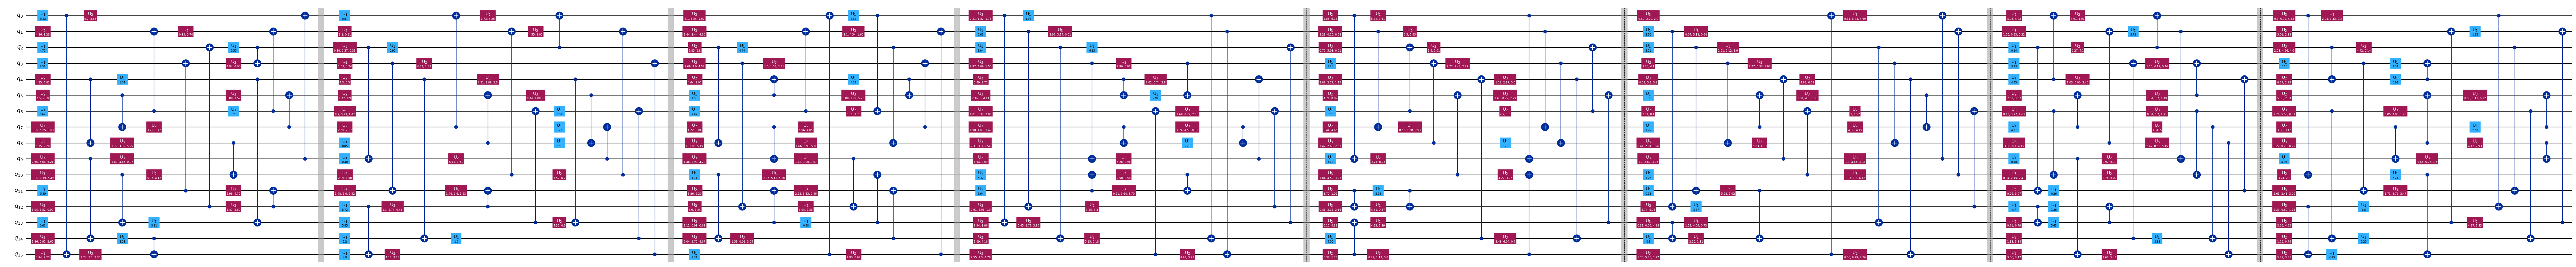

In [12]:
# Cell 3: Debug circuit by reading QASM and visualizing
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

# Read the generated QASM file
qasm_file = output_file  # or specify a path directly
print(f"Reading circuit from: {qasm_file}")

# Load circuit from QASM
qc = QuantumCircuit.from_qasm_file(str(qasm_file))

print(f"\nCircuit info:")
print(f"  Qubits: {qc.num_qubits}")
print(f"  Depth: {qc.depth()}")
print(f"  Gates: {qc.size()}")
print(f"  Operations: {qc.count_ops()}")

# Draw the circuit (will display automatically in Jupyter)
qc.draw(output='mpl', fold=-1, scale=0.8)